## Análisis de datos - Trabajo Práctico Individual
**Alumno: Lerner, Federico Ezequiel**

**2022 FIFA World Cup Squads - EDA**


Se realizará un EDA del dataset oficial de FIFA World Cup 2022, seleccionando el dataset de "Squads" (equipos), el cual contiene a todos los jugadores que participaron en dicho mundial con sus estadísticas PREVIAS al mundial.
<hr style="border:1px solid gray">

#### Importo librerias necesarias

In [385]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe

#### Funciones auxiliares (helper functions)



In [386]:
# Configuraciones estáticas para los gráficos
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90

In [387]:
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False, ax=None):
    """Histograma con media, ±1 std y opcionalmente kurtosis.

    Si se pasa ``ax``, dibuja en ese subplot existente; si no, crea su propia figura.
    Esto permite usarla tanto suelta como dentro de una grilla con plt.subplots().
    """
    skewness = data[column].skew()
    kurtosis = data[column].kurt()
    media    = data[column].mean()
    std      = data[column].std()

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)

    ax.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde, ax=ax)

    if snk:
        ax.text(0.70, 0.92, f'Asimetría: {skewness:.2f}', transform=ax.transAxes,
                fontsize=10, color='blue')
        ax.text(0.70, 0.84, f'Curtosis:  {kurtosis:.2f}',  transform=ax.transAxes,
                fontsize=10, color='blue')

    if mvd:
        ax.axvline(media, color='red', linestyle='--', label='Media')
        if shade:
            ax.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')

    ax.set_title(f'Histograma de "{column}"')
    ax.legend()

    if standalone:
        plt.tight_layout()
        plt.show()

In [388]:
def cuartiles(variable):
    Q1 = variable.quantile(0.25)
    Q2 = variable.quantile(0.50)   # equivalente a la mediana
    Q3 = variable.quantile(0.75)
    return Q1, Q2, Q3

In [389]:
def print_categorias(dataframe, columna, top=None):
    n_cat = dataframe[columna].nunique()
    print(f"Cantidad de categorías en '{columna}': {n_cat}\n")

    freq     = dataframe[columna].value_counts()
    freq_rel = dataframe[columna].value_counts(normalize=True).mul(100).round(2)
    tabla    = pd.DataFrame({'Frecuencia absoluta': freq, 'Frecuencia relativa (%)': freq_rel})

    if top is not None and n_cat > top:
        print(f"Mostrando top {top} de {n_cat} categorías:\n")
        print(tabla.head(top))
    else:
        print(tabla)

In [390]:
def plot_pie(data, column, ax=None, startangle=90, palette='pastel', title=None,
             top_n=None, top_n_labels=None):
    """Pie chart de las categorías de una columna.

    Parámetros
    ----------
    top_n : int, optional
        Agrupa las categorías más allá del top en una sola porción "Otros (N más)".
    top_n_labels : int, optional
        Si se pasa, etiqueta y muestra porcentaje SOLO en las top N porciones más
        grandes. Las demás se pintan pero sin texto (preserva las proporciones reales
        sin amontonar labels en variables con muchas categorías chicas).
    """
    counts = data[column].value_counts()

    if top_n is not None and len(counts) > top_n:
        top     = counts.iloc[:top_n]
        n_otros = len(counts) - top_n
        otros   = pd.Series({f'Otros ({n_otros} más)': counts.iloc[top_n:].sum()})
        counts  = pd.concat([top, otros])

    # Modo "etiquetar solo el top": labels y autopct se vacían para las porciones fuera del top
    if top_n_labels is not None and len(counts) > top_n_labels:
        labels = [name if i < top_n_labels else '' for i, name in enumerate(counts.index)]

        def _make_autopct(n):
            counter = {'i': 0}
            def autopct(pct):
                result = f'{pct:.1f}%' if counter['i'] < n else ''
                counter['i'] += 1
                return result
            return autopct
        autopct_func = _make_autopct(top_n_labels)
    else:
        labels       = list(counts.index)
        autopct_func = '%1.1f%%'

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.pie(counts, labels=labels, autopct=autopct_func,
           startangle=startangle,
           colors=sns.color_palette(palette, n_colors=len(counts)))
    ax.set_title(title if title else f'Distribución de "{column}"')
    ax.axis('equal')


def plot_frecuencias_relativas(data, column, ax=None, palette='viridis',
                               figsize=(9, 4), title=None, top_n=None):
    """Frecuencias relativas en barras horizontales.

    Si se pasa ``top_n``, recorta al top de categorías más frecuentes (ideal para
    variables con muchas categorías). El título indica top N de cuántas en total.

    Cada barra se anota con su porcentaje al final, así incluso barras visualmente
    chicas (típico de variables con cola larga como Club) son inmediatamente legibles.
    """
    relative_freq = data[column].value_counts(normalize=True)

    suffix = ''
    if top_n is not None and len(relative_freq) > top_n:
        suffix        = f' (top {top_n} de {len(relative_freq)})'
        relative_freq = relative_freq.iloc[:top_n]

    # Si la columna es categorical, value_counts conserva TODAS las categorías
    # en el índice (aunque algunas tengan frecuencia cero). Convierto a string
    # para que sns.barplot solo asigne una posición Y por categoría con datos.
    relative_freq.index = relative_freq.index.astype(str)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    sns.barplot(x=relative_freq.values, y=relative_freq.index,
                hue=relative_freq.index, palette=palette, ax=ax, legend=False)

    for j, val in enumerate(relative_freq.values):
        ax.text(val, j, f'  {val * 100:.1f}%', va='center', fontsize=9)

    ax.set_xlim(0, max(relative_freq.max(), 0.01) * 1.18)  # margen para que las anotaciones no se corten
    ax.set_title(title if title else f'Frecuencias relativas de "{column}"{suffix}')
    ax.set_xlabel('Frecuencia relativa')
    ax.set_ylabel(column)


def plot_distribucion_top(data, column, top_n=10, ax=None, figsize=(8, 6),
                          palette='viridis', title=None, include_otros=True):
    """Bar chart horizontal con el top N de categorías + barra 'Otros' opcional.

    Pensado para variables con muchas categorías (cola larga) donde un pie chart
    es ilegible. Cada barra muestra el conteo absoluto y el porcentaje del total.

    Parámetros
    ----------
    top_n : int
        Cantidad de categorías top a mostrar individualmente.
    include_otros : bool
        Si True y hay más de ``top_n`` categorías, agrega una barra final "Otros"
        que agrupa el resto (preserva la honestidad analítica sobre la cola larga).
    """
    counts = data[column].value_counts()
    total  = counts.sum()

    if include_otros and len(counts) > top_n:
        top       = counts.iloc[:top_n]
        n_otros   = len(counts) - top_n
        otros_cnt = counts.iloc[top_n:].sum()
        display   = pd.concat([top, pd.Series({f'Otros ({n_otros} más)': otros_cnt})])
    else:
        display = counts.iloc[:top_n]

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    colors = sns.color_palette(palette, n_colors=len(display))
    ax.barh(range(len(display)), display.values, color=colors)
    ax.set_yticks(range(len(display)))
    ax.set_yticklabels(display.index)
    ax.invert_yaxis()  # categoría más frecuente arriba

    for j, val in enumerate(display.values):
        pct = 100 * val / total
        ax.text(val, j, f'  {int(val)}  ({pct:.1f}%)', va='center', fontsize=9)

    ax.set_xlim(0, display.max() * 1.18)  # espacio para que no se corten las anotaciones
    ax.set_xlabel('Frecuencia')
    if title is None:
        suffix = f'top {top_n} de {len(counts)}' + (' + Otros' if include_otros and len(counts) > top_n else '')
        title  = f'Distribución de "{column}" ({suffix})'
    ax.set_title(title)
    ax.grid(axis='x', ls='--', alpha=0.4)
    sns.despine(ax=ax, left=False, bottom=False)

In [391]:
def plot_violin_box(data, num_col, cat_col, figsize=(12, 4), palette='pastel', title=None, order=None):
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)
    sns.violinplot(data=data, x=cat_col, y=num_col, hue=cat_col, order=order,
                   palette=palette, ax=axes[0], legend=False)
    axes[0].set_title(f'Violin: {num_col} vs. {cat_col}')
    axes[0].grid(axis='y', ls='--')
    sns.boxplot(data=data, x=cat_col, y=num_col, hue=cat_col, order=order,
                palette=palette, ax=axes[1], legend=False)
    axes[1].set_title(f'Boxplot: {num_col} vs. {cat_col}')
    axes[1].grid(axis='y', ls='--')
    plt.suptitle(title if title else f'{num_col} vs {cat_col}', fontsize=13)
    plt.tight_layout()
    plt.show()

## Descripción del dataset de equipos de FIFA y sus variables

| Variable     | Tipo de variable                  | Descripción                                                                  |
|--------------|-----------------------|------------------------------------------------------------------------------|
| `ID`         | Cuantitativa discreta         | Número entero correlativo del jugador para identificar al jugador. Hay un total de 831 jugadores.                                    |
| `Team`       | Categórica nominal    | Selección nacional a la que pertenece el jugador (32 selecciones).               |
| `Position`   | Categórica nominal   | Posición en el campo: Goalkeeper, Defender, Midfielder, Forward.             |
| `Player`     | Categórica nominal | Nombre del jugador. Algunos contienen `(captain)` identificando que es el capitán de su selección.                 |
| `Age`        | Cuantitativa continua     | Edad del jugador al momento del torneo (años).                               |
| `Caps`       | Cuantitativa discreta     | Cantidad de partidos jugados con la selección antes del Mundial.             |
| `Goals`      | Cuantitativa discreta     | Goles convertidos con la selección antes del Mundial.                        |
| `WC Goals`   | Cuantitativa discreta     | Goles previos en Copas del Mundo (acumulado histórico del jugador).          |
| `League`     | Categórica nominal    | Liga del país en la que juega su club.                                       |
| `Club`       | Categórica nominal    | Club al que pertenece el jugador.                                            |
| *`Is_Captain`     | Categórica nominal | Representa si el jugador es capitan o no. ***Extraida de la variable player**. 1 = Es capitán, 0 = No es capitán  |
---

Hay dos aclaraciones que me gustaría hacer:
* Is_Captain -> Esta variable no viene en el dataset, sin embargo en el campo de Player, se "tagea" a un capitán poniendo "(captain)" dentro del stirng. Por lo tanto, es una variable que voy a generar y extraer del campo Player.
* Hay dos variables (ID y Player -sin el captain- ) que son "identificadores", y no aportan valor ninguno al análisis. Por lo que las voy a excluir a la hora de analizar las variables.

#### Importamos el dataset
---


In [392]:
# Cargo el dataset
fifa_df = pd.read_csv('../datasets/2022_world_cup_squads.csv', encoding='cp1252')

#### Primera inspección
<hr style="border:1px solid gray">

#### Jugadores FIFA Mundial 2022
---

In [393]:
print(f"Dimensiones del dataset original: {fifa_df.shape}")
fifa_df.head()

Dimensiones del dataset original: (831, 10)


,ID,Team,Position,Player,Age,Caps,Goals,WC Goals,League,Club
0,1,Ecuador,Goalkeeper,Hernán Galíndez,35,12,0,0,Ecuador,Aucas
1,2,Ecuador,Defender,Félix Torres,25,17,2,0,Mexico,Santos Laguna
2,3,Ecuador,Defender,Piero Hincapié,20,21,1,0,Germany,Bayer Leverkusen
3,4,Ecuador,Defender,Robert Arboleda,31,33,2,0,Brazil,São Paulo
4,5,Ecuador,Midfielder,José Cifuentes,23,11,0,0,United States,Los Angeles FC


In [394]:
fifa_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831 entries, 0 to 830
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        831 non-null    int64 
 1   Team      831 non-null    object
 2   Position  831 non-null    object
 3   Player    831 non-null    object
 4   Age       831 non-null    int64 
 5   Caps      831 non-null    int64 
 6   Goals     831 non-null    int64 
 7   WC Goals  831 non-null    int64 
 8   League    831 non-null    object
 9   Club      831 non-null    object
dtypes: int64(5), object(5)
memory usage: 65.1+ KB


#### Identificación y ajuste de los tipos de variables

In [395]:
# En la variable Player, se encuentra el nombre del jugador y entre parentesis hay información de si es capitán
# Voy a extraer esta información, crear una nueva variable Is_Captain, y limpiar el nombre del jugador
fifa_df['Is_Captain'] = fifa_df['Player'].str.contains(r'\(captain\)', regex=True).astype(int)
fifa_df['Player']     = fifa_df['Player'].str.replace(r'\s*\(captain\)\s*', '', regex=True).str.strip()

# Muestreo
print(f"Cantidad de capitanes detectados: {fifa_df['Is_Captain'].sum()}")
print("\nMuestra de capitanes:")
fifa_df[fifa_df['Is_Captain']==1][['Player','Team','Position','Age','Caps','Goals']].head()

Cantidad de capitanes detectados: 31

Muestra de capitanes:


,Player,Team,Position,Age,Caps,Goals
12,Enner Valencia,Ecuador,Forward,33,74,35
29,Virgil van Dijk,Netherlands,Defender,31,49,6
61,Hassan Al-Haydos,Qatar,Midfielder,31,169,36
80,Kalidou Koulibaly,Senegal,Defender,31,64,0
112,Harry Kane,England,Forward,29,75,51


In [396]:
# Se corrigen los tipos de variables

fifa_numericas = ['Age', 'Caps', 'Goals', 'WC Goals']
fifa_cat_nom =['Team', 'Position','League', 'Club', 'Is_Captain']

dtype_map = {col: 'float64'  for col in fifa_numericas}  # Creamos un mapping para las numéricas
dtype_map.update({col: 'category' for col in fifa_cat_nom})  # Adicionamos el mapping para las nominales
dtype_map['Is_Captain'] = 'category'

fifa_df = fifa_df.astype(dtype_map) # Aplicamos el mapping al DataFrame

fifa_df.dtypes

ID               int64
Team          category
Position      category
Player          object
Age            float64
Caps           float64
Goals          float64
WC Goals       float64
League        category
Club          category
Is_Captain    category
dtype: object

In [397]:
# Creo una constante para forzar el orden visual alineado a las posiciones en los gráficos 
# Ya que visualmente siempre se suele mostrar arquero->defensa->medio->delantero ya que se lee mejor que ne orden alfabético.
POSITION_ORDER = ['Goalkeeper', 'Defender', 'Midfielder', 'Forward']

---
---
## Estadística descriptiva
---
---

### 1. Exploración de VARIABLES NUMÉRICAS

#### 1.1. Medidas de tendencia central: media, mediana y moda


#### Media, Mediana y Moda

In [398]:
tabla_central = pd.DataFrame({
    'Media':   fifa_df[fifa_numericas].mean().round(2),
    'Mediana': fifa_df[fifa_numericas].median(),
    'Moda':    fifa_df[fifa_numericas].mode().iloc[0]   # tomamos la primera moda si hay empates
})
tabla_central

,Media,Mediana,Moda
Age,26.97,27.0,25.0
Caps,34.04,24.0,1.0
Goals,4.71,1.0,0.0
WC Goals,0.17,0.0,0.0


#### 1.2. Medidas de tendencia central + histograma 

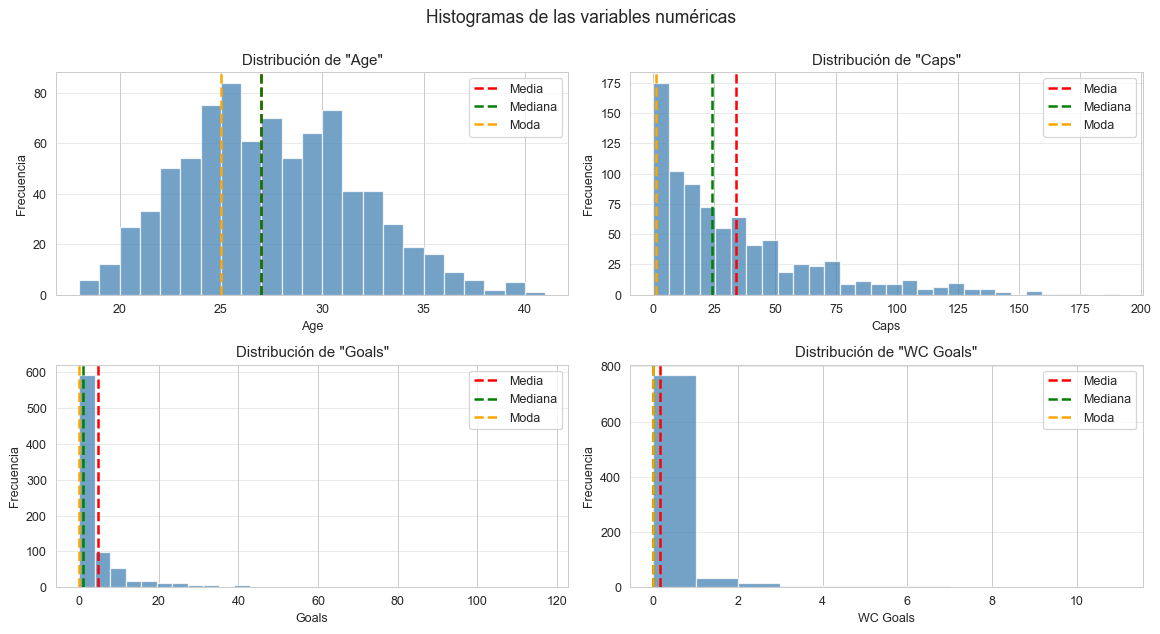

In [399]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()

#Para que los gráficos tengan los agrupamientos de bins representativos, calculo la cantidad de bins por columna para algunos casos
bins_por_columna = {
    'Age':      np.arange(fifa_df['Age'].min(), fifa_df['Age'].max() + 2),
    'Caps':     30,
    'Goals':    30,
    'WC Goals': np.arange(fifa_df['WC Goals'].min(), fifa_df['WC Goals'].max() + 2),
}

for i, col in enumerate(fifa_numericas):
    axes[i].hist(fifa_df[col],    bins=bins_por_columna[col],
        alpha=0.75, color='steelblue', edgecolor='white')
    axes[i].axvline(fifa_df[col].mean(),    color='red',    ls='--', lw=2, label='Media')
    axes[i].axvline(fifa_df[col].median(),  color='green',  ls='--', lw=2, label='Mediana')
    axes[i].axvline(fifa_df[col].mode()[0], color='orange', ls='--', lw=2, label='Moda')
    axes[i].set_title(f'Distribución de "{col}"')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()
    axes[i].grid(axis='y', alpha=0.4)

plt.suptitle('Histogramas de las variables numéricas', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

#### ¿Qué métrica representa mejor cada variable?

#### KDE: Kernel Density Estimation --> Busco estimar la función de densidad de probabilidad (PDF)

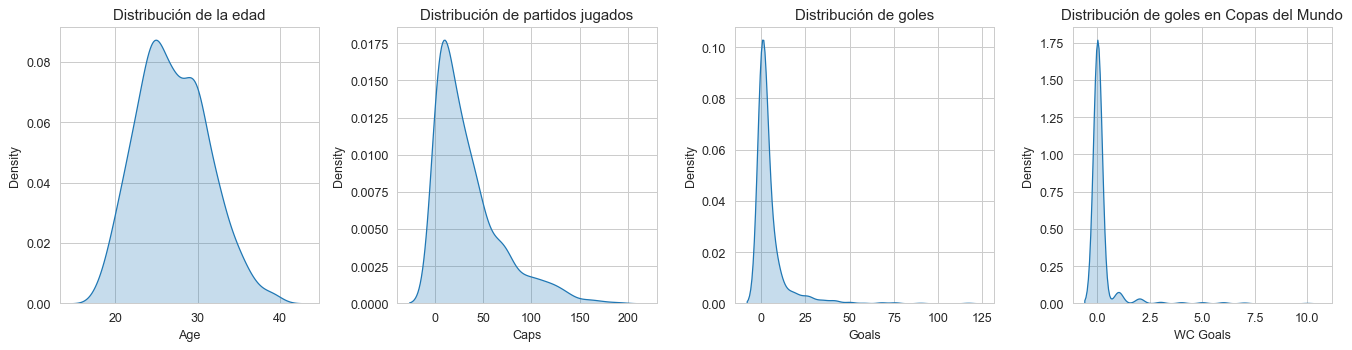

In [400]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

sns.kdeplot(data=fifa_df, x='Age', fill=True, ax=axes[0])
sns.kdeplot(data=fifa_df, x='Caps', fill=True, ax=axes[1])
sns.kdeplot(data=fifa_df, x='Goals', fill=True, ax=axes[2])
sns.kdeplot(data=fifa_df, x='WC Goals', fill=True, ax=axes[3])
axes[0].set_title('Distribución de la edad')
axes[1].set_title('Distribución de partidos jugados')
axes[2].set_title('Distribución de goles')
axes[3].set_title('Distribución de goles en Copas del Mundo')

plt.tight_layout()
plt.show()

#### Swarmplot

/Users/federicolerner/Documents/CEIA/1B/ADD/CEIA_Analisis_de_datos/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 31.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/federicolerner/Documents/CEIA/1B/ADD/CEIA_Analisis_de_datos/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 31.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/federicolerner/Documents/CEIA/1B/ADD/CEIA_Analisis_de_datos/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 31.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/federicolerner/Documents/CEIA/1B/ADD/CEIA_Analisis_de_datos/.venv/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 53.4% o

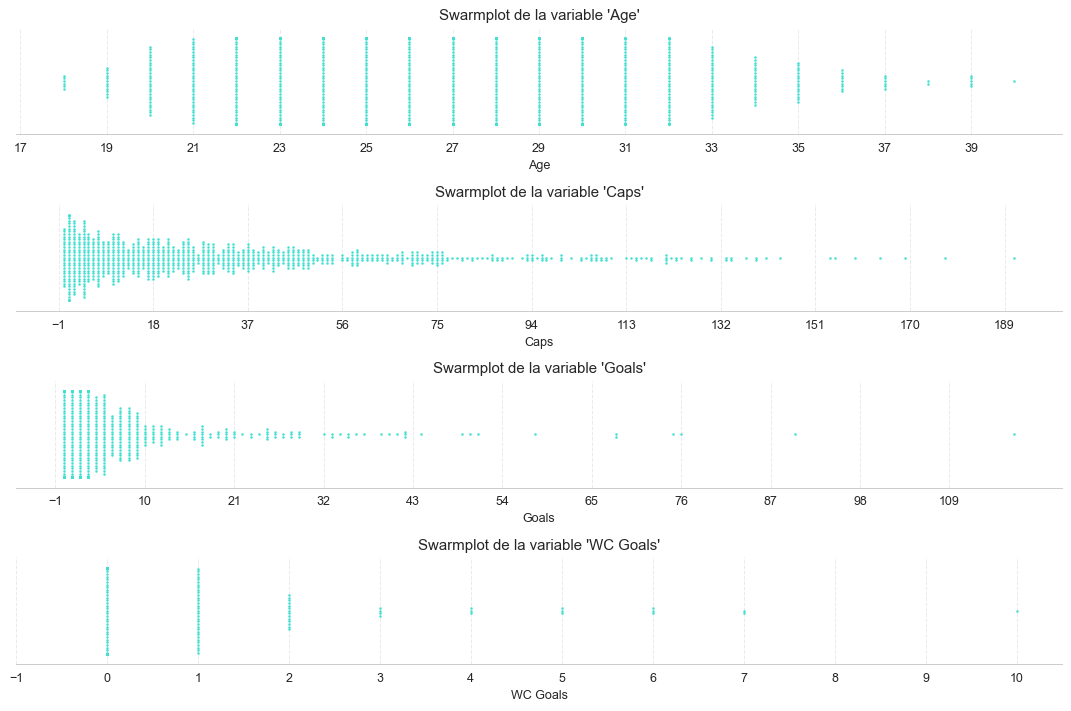

In [401]:
fig, axes = plt.subplots(4, 1, figsize=(12, 8))

for i, col in enumerate(fifa_numericas):
    sns.swarmplot(x=fifa_df[col], color='turquoise', size=2, ax=axes[i])

    step = max(1, int((fifa_df[col].max() - fifa_df[col].min()) / 10))
    axes[i].set_xticks(np.arange(int(fifa_df[col].min()) - 1, int(fifa_df[col].max()) + 1, step))
    axes[i].grid(axis='x', which='major', linestyle='--', alpha=0.4)
    axes[i].set_yticks([])
    axes[i].set_ylabel("")
    axes[i].set_xlabel(col)
    axes[i].set_title(f"Swarmplot de la variable '{col}'")
    sns.despine(ax=axes[i], left=True)

plt.tight_layout()
plt.show()

### 1.4. Medidas de dispersión: varianza y desviación estándar
<hr style="border:1px solid gray">


In [402]:
tabla_disp = pd.DataFrame({
    'Mínimo':      fifa_df[fifa_numericas].min(),
    'Máximo':      fifa_df[fifa_numericas].max(),
    'Rango':    fifa_df[fifa_numericas].max() - fifa_df[fifa_numericas].min(),
    'Media':   fifa_df[fifa_numericas].mean().round(2),
    'Varianza': fifa_df[fifa_numericas].var().round(2),
    'Desvío Estándar':      fifa_df[fifa_numericas].std().round(2),
})
tabla_disp

,Mínimo,Máximo,Rango,Media,Varianza,Desvío Estándar
Age,18.0,40.0,22.0,26.97,18.10,4.25
Caps,0.0,191.0,191.0,34.04,1152.33,33.95
Goals,0.0,117.0,117.0,4.71,107.96,10.39
WC Goals,0.0,10.0,10.0,0.17,0.64,0.80


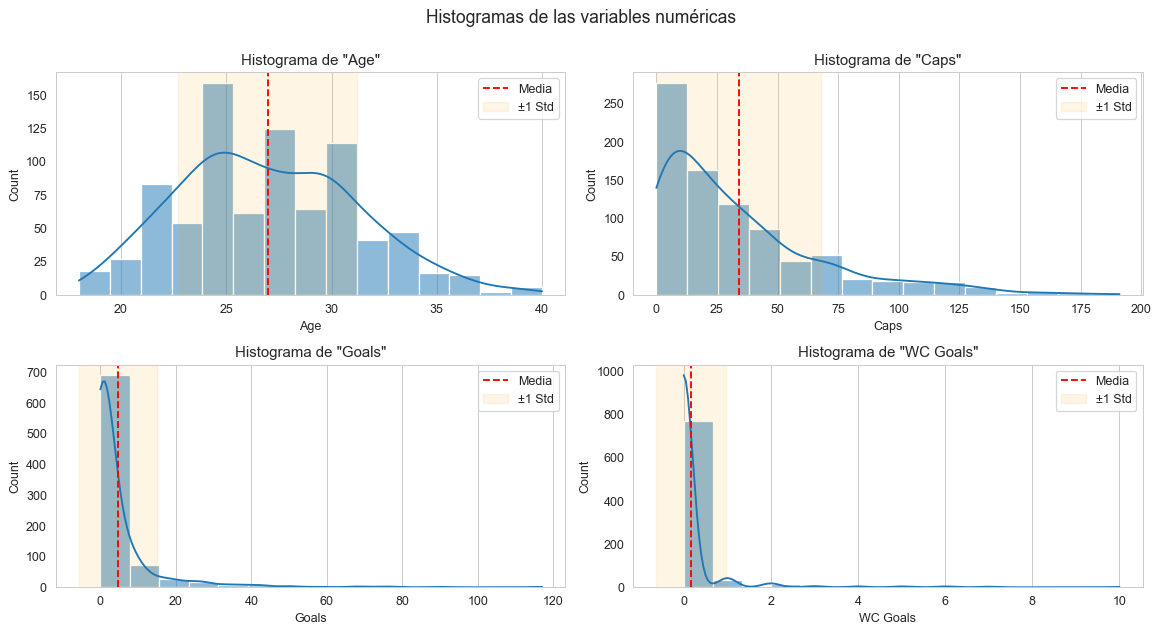

In [403]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()

for i, col in enumerate(fifa_numericas):
    plot_histograma(fifa_df, col, ax=axes[i])

plt.suptitle('Histogramas de las variables numéricas', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### 1.5. Cuartiles y rango intercuartil
<hr style="border:1px solid gray">


In [404]:
# Tabla con IQR para todas las numéricas
iqr_tabla = pd.DataFrame({
    'Q1':  fifa_df[fifa_numericas].quantile(0.25),
    'Q2':  fifa_df[fifa_numericas].quantile(0.50),
    'Q3':  fifa_df[fifa_numericas].quantile(0.75),
    'IQR': fifa_df[fifa_numericas].quantile(0.75) - fifa_df[fifa_numericas].quantile(0.25),
})
iqr_tabla

,Q1,Q2,Q3,IQR
Age,24.0,27.0,30.0,6.0
Caps,8.0,24.0,47.0,39.0
Goals,0.0,1.0,5.0,5.0
WC Goals,0.0,0.0,0.0,0.0


#### Visualización con Boxplots

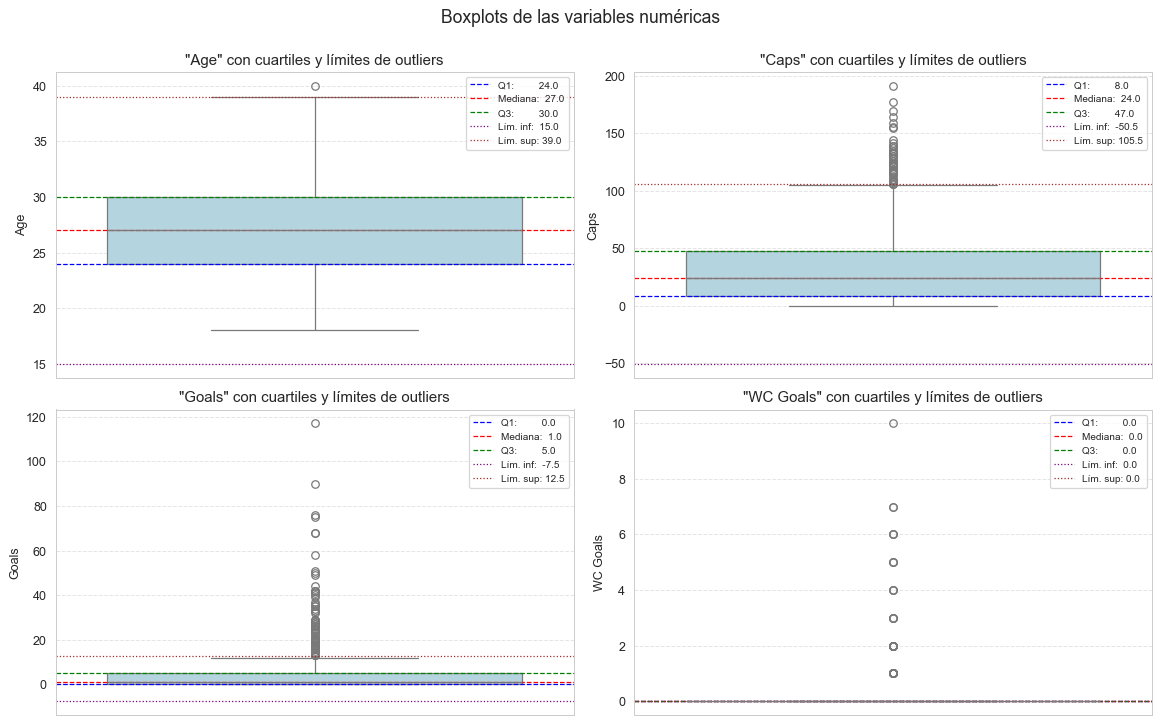

In [405]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for i, col in enumerate(fifa_numericas):
    Q1  = iqr_tabla.loc[col, 'Q1']
    Q2  = iqr_tabla.loc[col, 'Q2']
    Q3  = iqr_tabla.loc[col, 'Q3']
    IQR = iqr_tabla.loc[col, 'IQR']

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    sns.boxplot(data=fifa_df, y=col, color="lightblue", ax=axes[i])
    axes[i].axhline(Q1,          color='blue',   linestyle='--', linewidth=1, label=f'Q1:         {Q1:.1f}')
    axes[i].axhline(Q2,          color='red',    linestyle='--', linewidth=1, label=f'Mediana:  {Q2:.1f}')
    axes[i].axhline(Q3,          color='green',  linestyle='--', linewidth=1, label=f'Q3:         {Q3:.1f}')
    axes[i].axhline(lower_limit, color='purple', linestyle=':',  linewidth=1, label=f'Lím. inf:  {lower_limit:.1f}')
    axes[i].axhline(upper_limit, color='brown',  linestyle=':',  linewidth=1, label=f'Lím. sup: {upper_limit:.1f}')
    axes[i].set_title(f'"{col}" con cuartiles y límites de outliers')
    axes[i].legend(fontsize=8, loc='upper right')
    axes[i].grid(axis='y', ls='--', alpha=0.5)

plt.suptitle('Boxplots de las variables numéricas', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

#### Violinplot

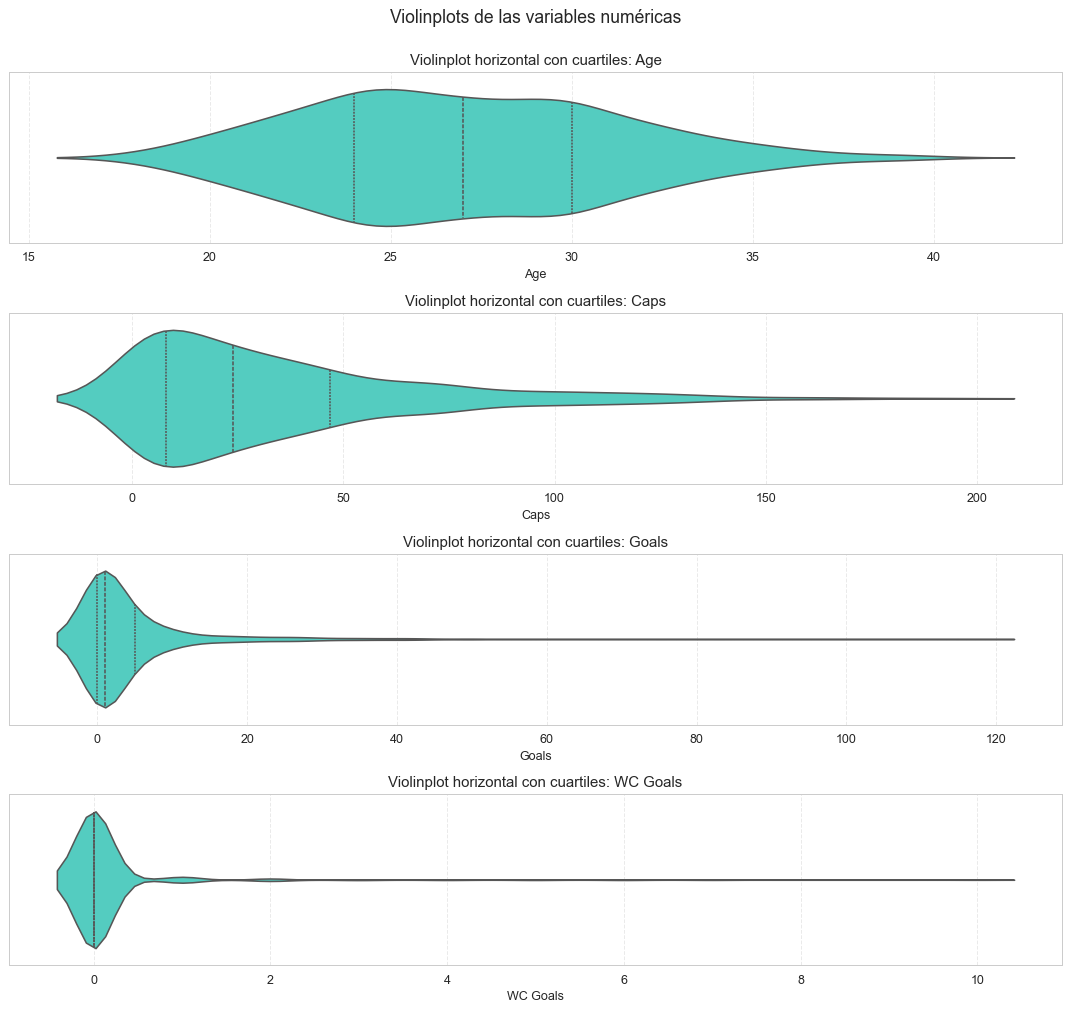

In [406]:
fig, axes = plt.subplots(len(fifa_numericas), 1, figsize=(12, 2.8 * len(fifa_numericas)))

for i, col in enumerate(fifa_numericas):
    sns.violinplot(data=fifa_df, x=col, color='turquoise', inner='quart', ax=axes[i])
    axes[i].set_title(f'Violinplot horizontal con cuartiles: {col}')
    axes[i].grid(axis='x', ls='--', alpha=0.4)

plt.suptitle('Violinplots de las variables numéricas', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### 1.6. Medidas de forma: skewness (asimetría) y curtosis
<hr style="border:1px solid gray">


In [407]:
asim_curt = pd.DataFrame({
    'Asimetría': fifa_df[fifa_numericas].skew().round(3),
    'Curtosis':         fifa_df[fifa_numericas].kurtosis().round(3)
})
asim_curt

,Asimetría,Curtosis
Age,0.297,-0.337
Caps,1.506,2.192
Goals,4.822,32.364
WC Goals,6.818,56.136


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


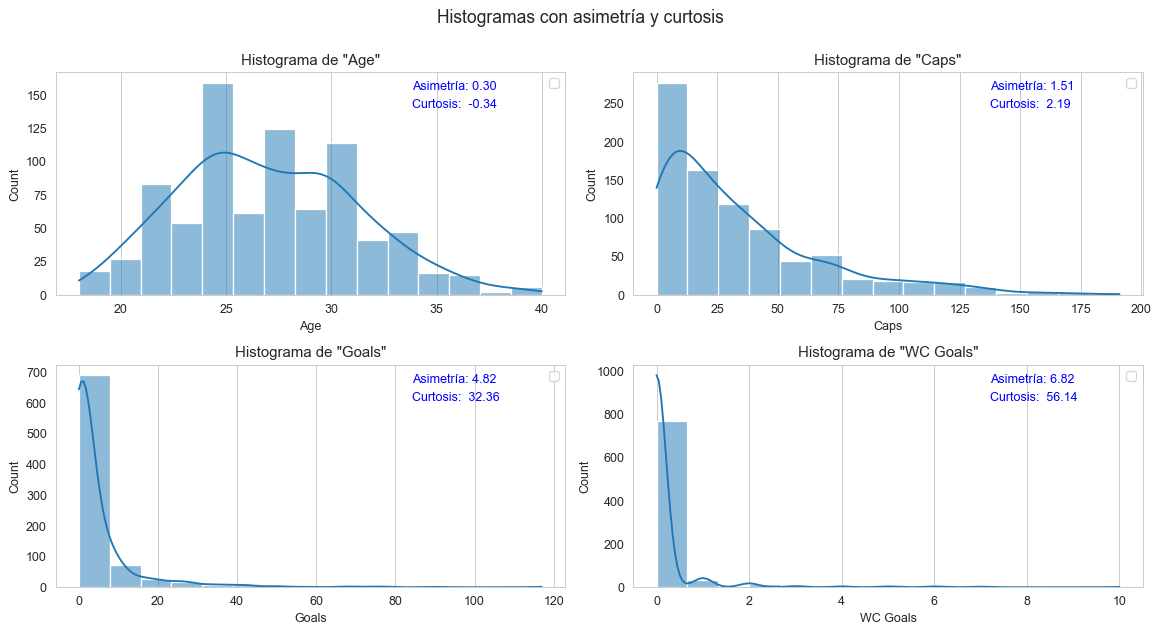

In [408]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes = axes.flatten()

for i, col in enumerate(fifa_numericas):
    plot_histograma(fifa_df, col, mvd=False, snk=True, ax=axes[i])

plt.suptitle('Histogramas con asimetría y curtosis', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### 1.7. Estadística descriptiva completa 
<hr style="border:1px solid gray">


In [409]:
print("Estadística descriptiva del dataset FIFA Mundial 2022:\n")
fifa_df.describe().round(3)

Estadística descriptiva del dataset FIFA Mundial 2022:



,ID,Age,Caps,Goals,WC Goals
count,831.000,831.000,831.000,831.000,831.000
mean,416.000,26.974,34.043,4.705,0.171
std,240.033,4.254,33.946,10.390,0.799
min,1.000,18.000,0.000,0.000,0.000
25%,208.500,24.000,8.000,0.000,0.000
50%,416.000,27.000,24.000,1.000,0.000
75%,623.500,30.000,47.000,5.000,0.000
max,831.000,40.000,191.000,117.000,10.000


In [410]:
# Con Scipy
ed_fifa = st.describe(fifa_df[fifa_numericas].dropna())

ed_fifa_df = pd.DataFrame({
    'Observaciones': ed_fifa.nobs,
    'Min':           ed_fifa.minmax[0],
    'Max':           ed_fifa.minmax[1],
    'Media':         ed_fifa.mean,
    'Varianza':      ed_fifa.variance,
    'Asimetría':     ed_fifa.skewness,
    'Curtosis':      ed_fifa.kurtosis,
}, index=fifa_numericas)

ed_fifa_df


,Observaciones,Min,Max,Media,Varianza,Asimetría,Curtosis
Age,831,18.0,40.0,26.973526,18.098093,0.296327,-0.341988
Caps,831,0.0,191.0,34.043321,1152.333061,1.503583,2.171296
Goals,831,0.0,117.0,4.705174,107.959961,4.813268,32.162354
WC Goals,831,0.0,10.0,0.170878,0.638235,6.805298,55.791192


## Análisis de las variables numéricas

- **`Age`** es la única variable que se comporta de forma cercana a la normal: media cercana a la mediana, aprox 27, asimetría chica (aprox 0.30) y curtosis levemente negativa (aprox −0.34, una distribución un poco más "aplastada" que una normal). El rango va de 18 a 41 años, el IQR de aprox 6 y prácticamente no hay outliers. **Esto tiene mucho sentido: el plantel de un Mundial es una población muy seleccionada, sin lugar para extremos.**

- **`Caps`** ya muestra un sesgo claro a la derecha: la mediana ronda los 24 partidos, pero la media salta a aprox 34 y el máximo llega cerca de 190. La cola larga refleja que hay jugadores muy jóvenes (debutantes con la selección) junto con figuras históricas que llevan más de 100 partidos internacionales.

- **`Goals`** y **`WC Goals`** presentan muchos valores con 0. La moda es 0 en ambos, la mediana es 0 o 1, y la asimetría/curtosis son altísimas (asimetría > 4 y > 6, curtosis > 30 y > 50 respectivamente). Algo muy esperable es que todos los arqueros y defensores tienen 0 goles por la estructura del juego, siendo que solo unos pocos mediocampistas o delanteros convierten goles.

---
### 2. Exploración de VARIABLES CATEGÓRICAS



#### 2.1. Frecuencias y categorías

In [411]:
for col in fifa_cat_nom:
    print('=' * 60)
    print_categorias(fifa_df, col, top=10)
    print()

Cantidad de categorías en 'Team': 32

Mostrando top 10 de 32 categorías:

               Frecuencia absoluta  Frecuencia relativa (%)
Team                                                       
Argentina                       26                     3.13
Australia                       26                     3.13
Uruguay                         26                     3.13
United States                   26                     3.13
Tunisia                         26                     3.13
Switzerland                     26                     3.13
Spain                           26                     3.13
South Korea                     26                     3.13
Serbia                          26                     3.13
Senegal                         26                     3.13

Cantidad de categorías en 'Position': 4

            Frecuencia absoluta  Frecuencia relativa (%)
Position                                                
Midfielder                  273                   

**Hay 4 variables categóricas:**
* Team -> Cada equipo tiene 32 jugadores.
* Position -> Contiene las 4 posiciones generales de los jugadores: Goalkeeper, Defender, Midfielder y Forward.
* League -> Contiene la liga de cada jugador.
* Club -> Contiene el club de cada jugador.

#### 2.2. Descripción de categóricas con la función $\texttt{describe}$

In [412]:
fifa_df.describe(include='category')

,Team,Position,League,Club,Is_Captain
count,831,831,831,831,831
unique,32,4,44,295,2
top,Argentina,Midfielder,England,Bayern Munich,0
freq,26,273,158,17,800


#### 2.3. Visualizaciones para categóricas

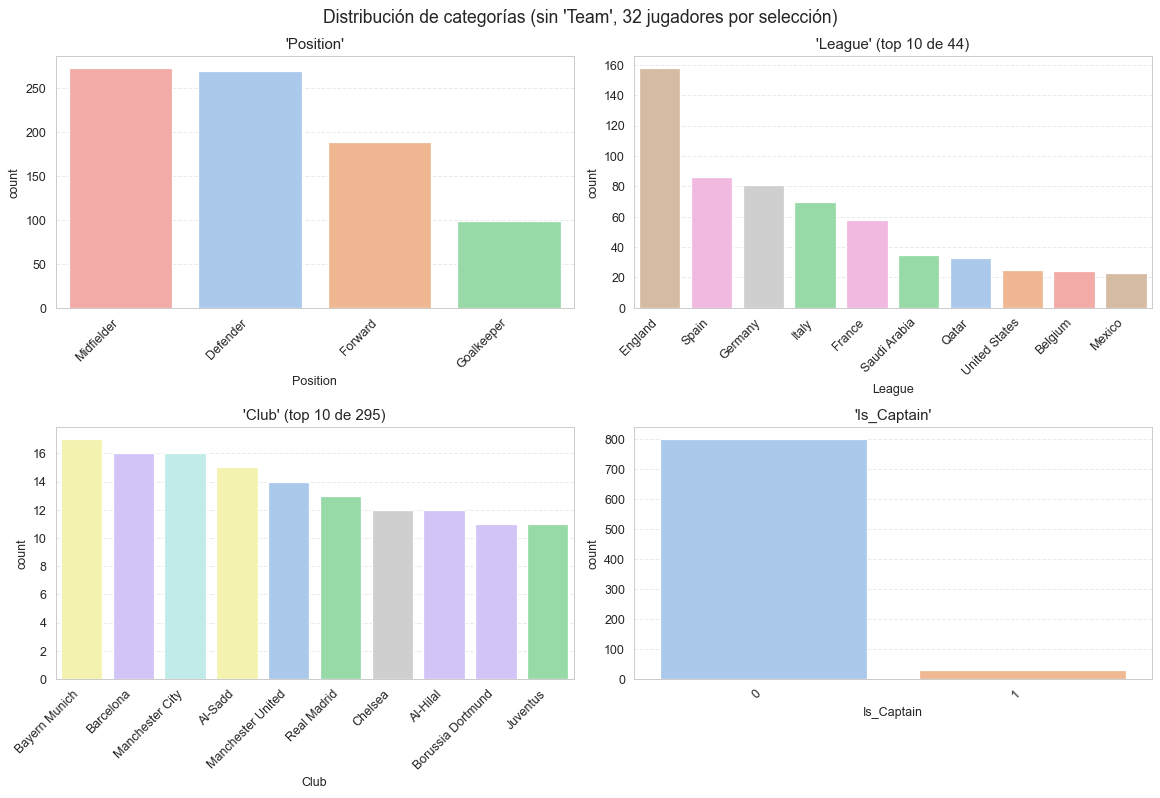

In [413]:
# Excluyo 'Team' porque porque sabemos que cada selección tiene 32 jugadores, # por lo que el gráfico de barras no aportaría valor.
# Para variables con muchas categorías (Club, League) limito a las TOP 10 más frecuentes.
# Las que tienen pocas (Position, Is_Captain) se muestran completas.
TOP_N = 10
cols_countplot = [c for c in fifa_cat_nom if c != 'Team']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(cols_countplot):
    n_total = fifa_df[col].nunique()
    order   = fifa_df[col].value_counts().nlargest(TOP_N).index

    sns.countplot(x=col, data=fifa_df, hue=col, palette='pastel',
                  order=order, legend=False, ax=axes[i])

    suffix = f' (top {TOP_N} de {n_total})' if n_total > TOP_N else ''
    axes[i].set_title(f"'{col}'{suffix}")
    axes[i].tick_params(axis='x', rotation=45)
    for label in axes[i].get_xticklabels():
        label.set_ha('right')
    axes[i].grid(axis='y', ls='--', alpha=0.4)

plt.suptitle("Distribución de categorías (sin 'Team', 32 jugadores por selección)", fontsize=14)
plt.tight_layout()
plt.show()

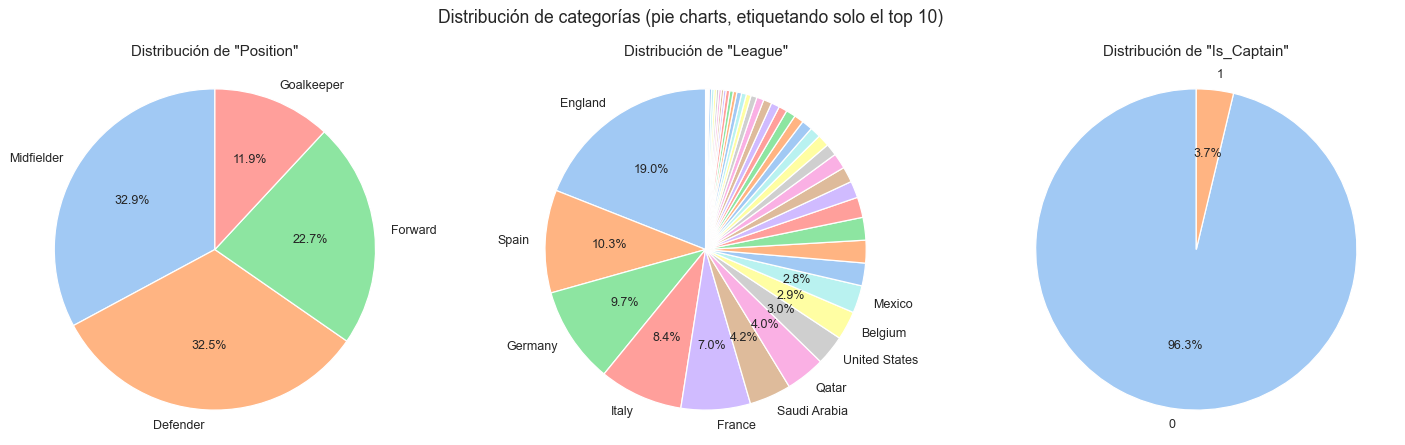

In [414]:
# Nuevamente excluyo 'Team' por las razones ya mencionadas.
# Para 'League' mantengo las etiquetas solamente para las 10 más grandes para que no se superpongan.
cols_pie = [c for c in fifa_cat_nom if c not in ('Team', 'Club')]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes = axes.flatten()

for i, col in enumerate(cols_pie):
    plot_pie(fifa_df, col, ax=axes[i], top_n_labels=10)

plt.suptitle("Distribución de categorías (pie charts, etiquetando solo el top 10)", fontsize=14)
plt.tight_layout()
plt.show()

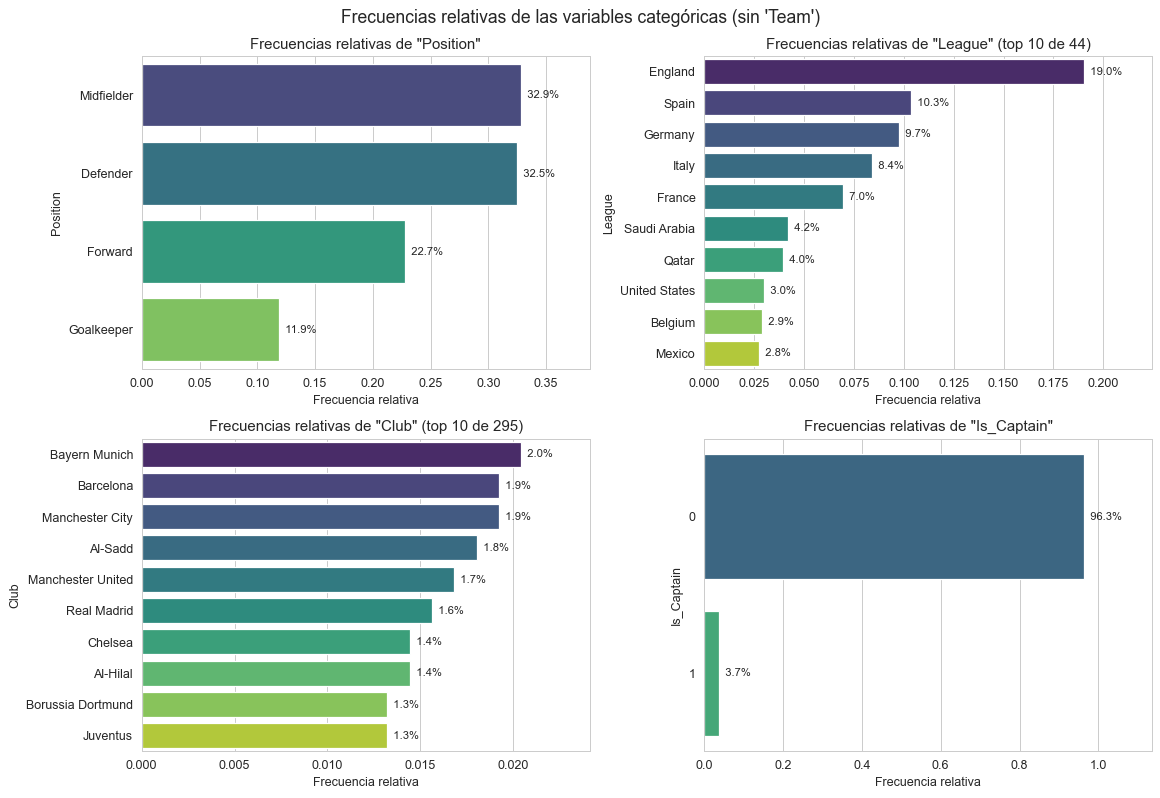

In [415]:
# Oculto team nuevamente por las razones ya mencionadas.
# Top 10 para que las variables con muchos valores sean legibles.
cols_freq = [c for c in fifa_cat_nom if c != 'Team']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, col in enumerate(cols_freq):
    plot_frecuencias_relativas(fifa_df, col, ax=axes[i], top_n=10)

plt.suptitle("Frecuencias relativas de las variables categóricas (sin 'Team')", fontsize=14)
plt.tight_layout()
plt.show()

## Análisis de las variables categóricas

- **`Team`**: por como funcioan el mundial, todas las selecciones tienen 32 jugadores, por lo que no aporta información de distribución.. Solamente es útil como variable de agrupamiento. Es pore esto que la excluí de la mayoría de los gráficos.

- **`Position`** está repartida de forma "razonable": Midfielders (aprox 33%) y Defenders (aprox 32.5%) son las posiciones más comunes, seguidos por Forwards (aprox 23%) y Goalkeepers (aprox 12%). La proporción 4:4:3:1 entre Defender, Midfielder, Forward y Goalkeeper es coherente con la composición típica de un plantel. Hay un solo arquero, luego hay 3, 4 o 5 defensores, 3, 4 o 5 mediocampistas, y generalmente 1, 2 o 3 delanteros.

- **`League`** muestra una fuerte concentración en las grandes ligas europeas: la Premier League (Inglaterra) aporta aprox el 19% de los jugadores, seguida por La Liga de España (aprox 10%), Bundesliga de Alemania (aprox 10%), Serie A de Italia (aprox 8%) y Ligue 1 de Francia(aprox 7%). El top 5 ya cubre más de la mitad del plantel mundial.

- **`Club`** es donde la "cola larga" es más impactante: De 295 clubes distintos en total, el club que más jugadores aporta es el Bayern Munich, que aporta 17 jugadores (aprox 2%). No hay ningún club dominante, sin embargo hay un grupo de clubes top que aportan entre 10 y 17 jugadores cada uno, y luego hay una cola larguísima de clubes con 1-2 jugadores. Es por esto que el pie chart de Club resultó ilegible y conviene representarlo con un bar chart con el top N.

- **`Is_Captain`** es una variable **muy desbalanceada** (96.3% vs 3.7%). Esto era algo esperable de antemano: en cada selección hay solamente un capitán de 32 jugadores.


---
### 3. Relaciones entre variables

#### 3.1. Numérica-numérica

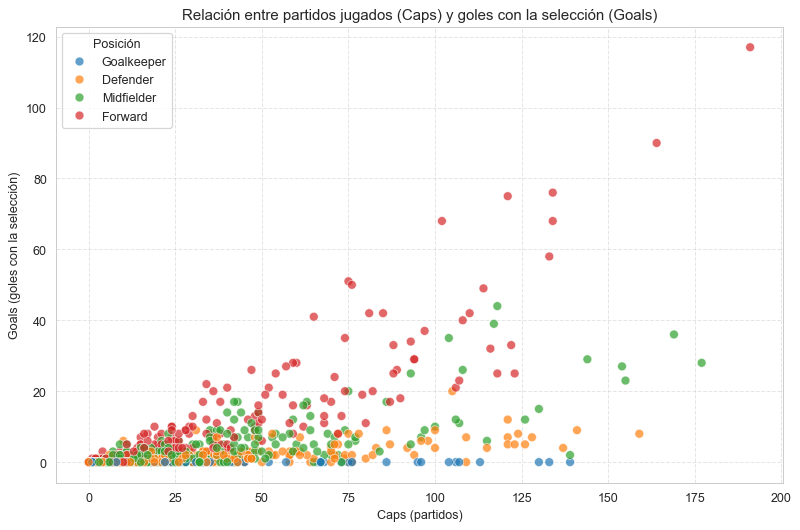

In [416]:
# Caps (partidos jugados con la selección)
# Contra Goals (goles totales con la selección).
# Coloreamos por Position
plt.figure(figsize=(9, 6))
sns.scatterplot(data=fifa_df, x='Caps', y='Goals',
                hue='Position', hue_order=POSITION_ORDER,
                alpha=0.7, s=50)
plt.grid(ls='--', alpha=0.5)
plt.title('Relación entre partidos jugados (Caps) y goles con la selección (Goals)')
plt.xlabel('Caps (partidos)')
plt.ylabel('Goals (goles con la selección)')
plt.legend(title='Posición', loc='upper left')
plt.tight_layout()
plt.show()

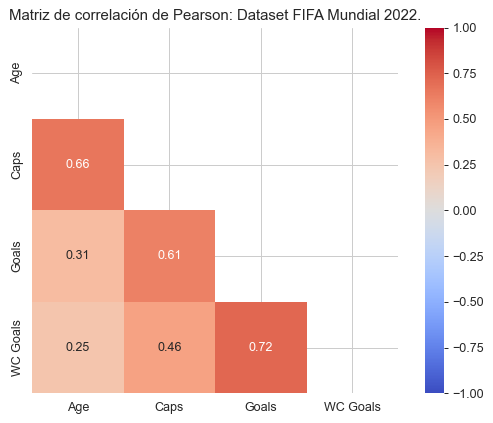

In [417]:
# Matriz de Pearson cortada para no ver información redundante
corr_matrix = fifa_df[fifa_numericas].corr()
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool)) 

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, mask=mascara) # Se filtra aplicando una máscara
plt.title('Matriz de correlación de Pearson: Dataset FIFA Mundial 2022.')
plt.tight_layout()
plt.show()

**Análisis:**

- La correlación más fuerte es **`Goals` ↔ `WC Goals` (0.72)**. Tiene sentido ya que los goles totales con la selección incluyen a los goles convertidos en Mundiales. Es prácticamente una relación de inclusión.

- **`Caps` ↔ `Age` (0.66)**: cuanta más edad tiene un jugador, más partidos internacionales acumuló. Otra relación que puede llegar a ser intuitiva.

- **`Caps` ↔ `Goals` (0.61)**: los grandes goleadores también son los jugadores con más experiencia internacional. Pero la dispersión que se puede ver el scatterplot es grande: hay defensores y arqueros con 100+ partidos y 0-2 goles, lo que tracciona la correlación lineal hacia abajo. El color por `Position` en el scatter deja ver que el gráfico se separa en dos sub-poblaciones: los goleadores naturales (delanteros, en rosa) que escalan con `Caps`, y los no-goleadores (arqueros, defensores) que se quedan pegados al eje X.

- Todas las correlaciones son **positivas y moderadas** (entre 0.25 y 0.72). No aparece ninguna relación negativa, algo razonable cuando las cuatro variables miden, de una u otra forma, "productividad" o "experiencia" del jugador.


#### 3.2. Categórica-categórica

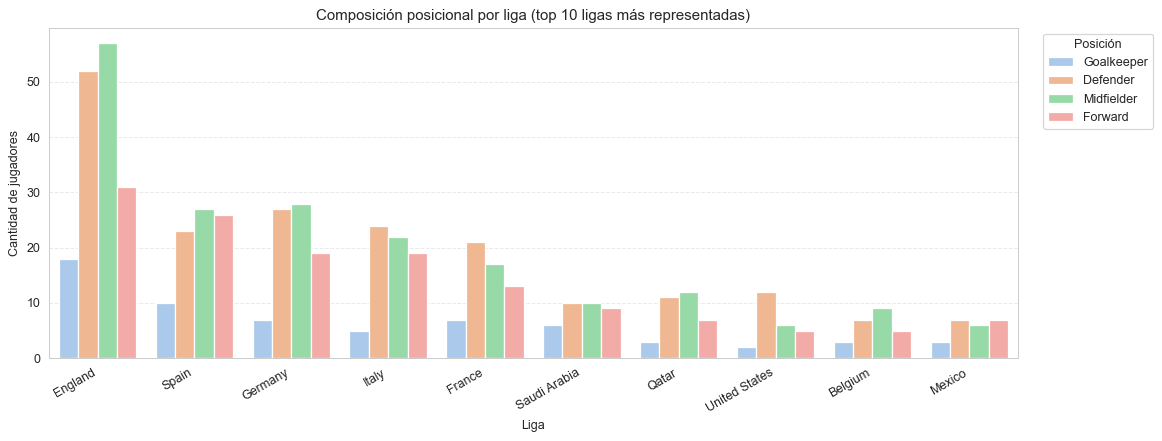

In [418]:
# Categórica vs categórica: ¿la composición posicional varía entre ligas?
# Tomo las top 10 ligas más representadas y las cruzo con Position.
# La pregunta: ¿hay ligas con sesgo posicional (más defensores, más delanteros, etc.)?
top_leagues = fifa_df['League'].value_counts().nlargest(10).index.tolist()
df_top_leagues = fifa_df[fifa_df['League'].isin(top_leagues)]

plt.figure(figsize=(13, 5))
sns.countplot(data=df_top_leagues, x='League', hue='Position',
              order=top_leagues, hue_order=POSITION_ORDER, palette='pastel')
plt.grid(ls='--', axis='y', alpha=0.4)
plt.title("Composición posicional por liga (top 10 ligas más representadas)")
plt.xlabel('Liga')
plt.ylabel('Cantidad de jugadores')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Posición', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

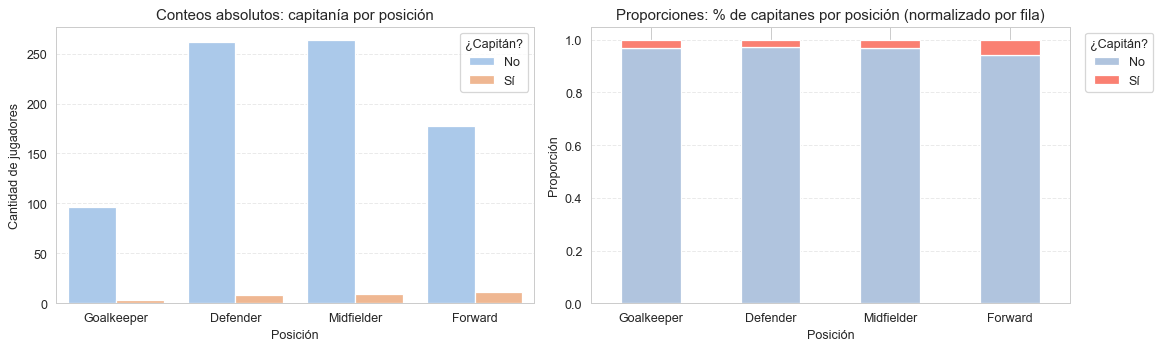

In [419]:
# ¿Hay alguna posición predominante entre los capitanes?
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(x='Position', hue='Is_Captain', data=fifa_df,
              order=POSITION_ORDER, palette='pastel', ax=axes[0])
axes[0].grid(ls='--', axis='y', alpha=0.4)
axes[0].set_title("Conteos absolutos: capitanía por posición")
axes[0].set_xlabel('Posición')
axes[0].set_ylabel('Cantidad de jugadores')
axes[0].legend(title='¿Capitán?', labels=['No', 'Sí'])

ct_position_captain = pd.crosstab(fifa_df['Position'], fifa_df['Is_Captain'], normalize='index')
ct_position_captain = ct_position_captain.loc[POSITION_ORDER]
ct_position_captain.plot(kind='bar', stacked=True,
                          color=['lightsteelblue', 'salmon'], ax=axes[1])
axes[1].grid(ls='--', axis='y', alpha=0.4)
axes[1].set_title("Proporciones: % de capitanes por posición (normalizado por fila)")
axes[1].set_xlabel('Posición')
axes[1].set_ylabel('Proporción')
axes[1].legend(title='¿Capitán?', labels=['No', 'Sí'], bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

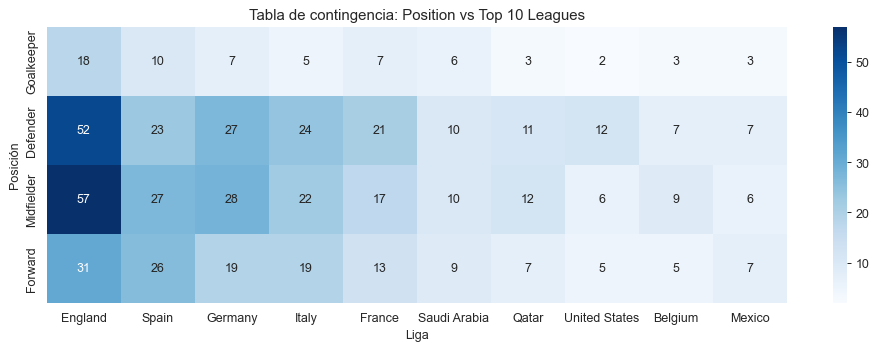

In [420]:
# Heatmap 2D: cantidad de jugadores por (Position, Top 10 Leagues).
# Cada celda muestra cuántos jugadores hay en esa combinación.
top_leagues = fifa_df['League'].value_counts().nlargest(10).index.tolist()
df_top_leagues = fifa_df[fifa_df['League'].isin(top_leagues)]

cross_tab = pd.crosstab(df_top_leagues['Position'], df_top_leagues['League'])
cross_tab = cross_tab.loc[POSITION_ORDER, top_leagues]  # orden semántico de filas y columnas

plt.figure(figsize=(11, 4))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues')
plt.title('Tabla de contingencia: Position vs Top 10 Leagues')
plt.xlabel('Liga')
plt.ylabel('Posición')
plt.tight_layout()
plt.show()

Tabla de contingencia normalizada

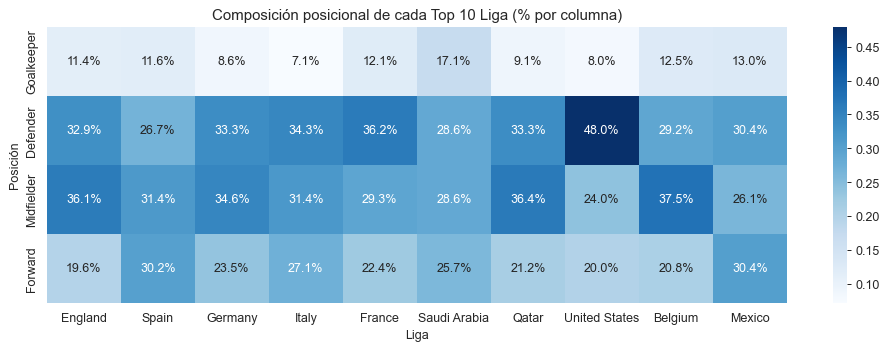

In [421]:
cross_tab_col = pd.crosstab(df_top_leagues['Position'], df_top_leagues['League'],
                             normalize='columns')
cross_tab_col = cross_tab_col.loc[POSITION_ORDER, top_leagues]

plt.figure(figsize=(11, 4))
sns.heatmap(cross_tab_col, annot=True, fmt='.1%', cmap='Blues')
plt.title('Composición posicional de cada Top 10 Liga (% por columna)')
plt.xlabel('Liga')
plt.ylabel('Posición')
plt.tight_layout()
plt.show()

**Análisis:**

- El countplot **`Position × Top 10 Leagues`** y el heatmap absoluto cuentan la misma historia desde dos ángulos: **England es la liga más representada en todas las posiciones**, no solo en total.

- El heatmap nos muestra que la **composición de la posición varía poco entre las grandes ligas**. Las top 5 (England, Spain, Germany, Italy, France) están todas en un rango muy parecido (alrededor de 30-37% defensores, 25-35% mediocampistas, 15-25% delanteros y 7-15% arqueros). Las desviaciones se ven solo en ligas más chicas (Qatar, USA, Mexico), donde los conteos son bajos y un par de jugadores cambia mucho la proporción.


#### 3.3. Numéricas-categóricas

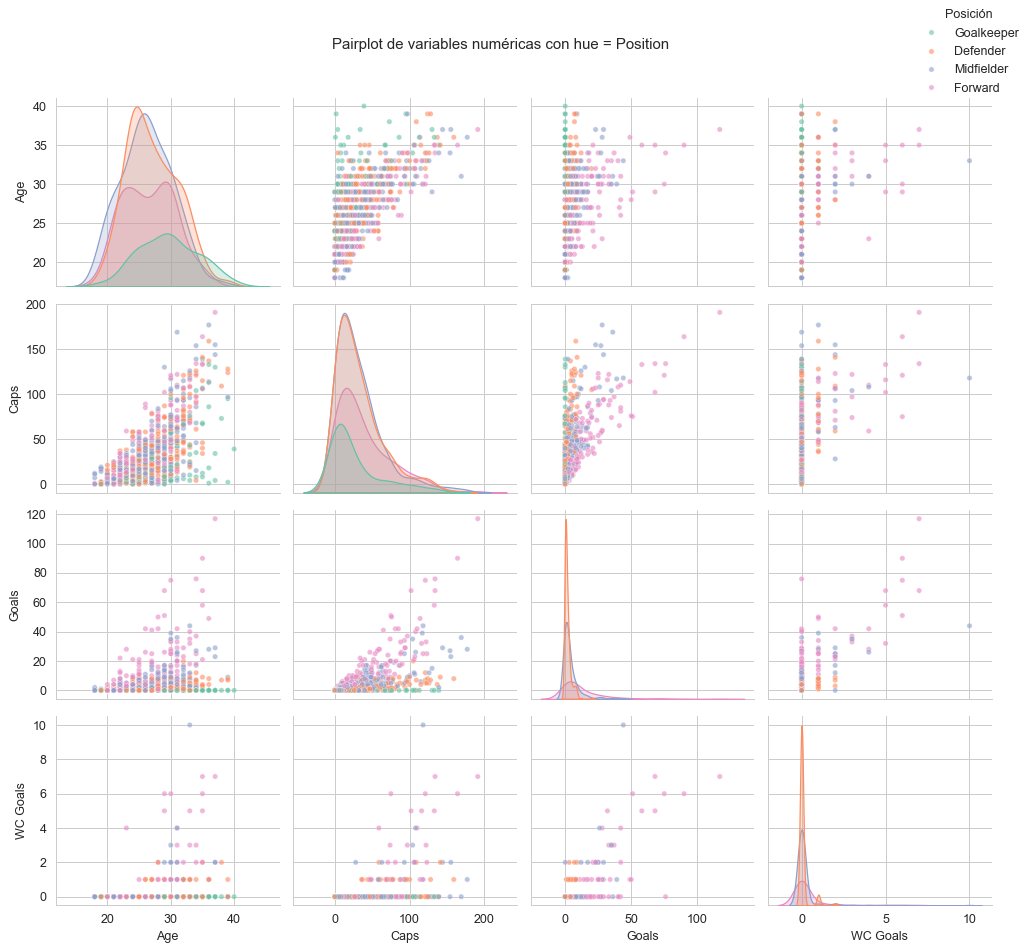

In [422]:
# Pairplot de las 4 variables numéricas con hue por Position.
grafico = sns.pairplot(
    data=fifa_df,
    vars=fifa_numericas,
    hue='Position',
    hue_order=POSITION_ORDER,
    palette='Set2',
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 18},
)
grafico.figure.suptitle(
    'Pairplot de variables numéricas con hue = Position',
    y=1.02,
)
grafico.legend.set_bbox_to_anchor((1.02, 1))
grafico.legend.set_title('Posición')

plt.tight_layout()
plt.show()

#### Boxplots y violinplots

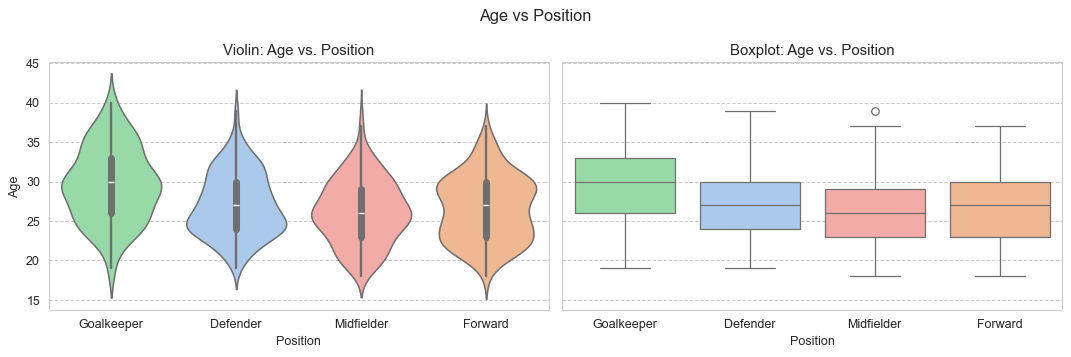

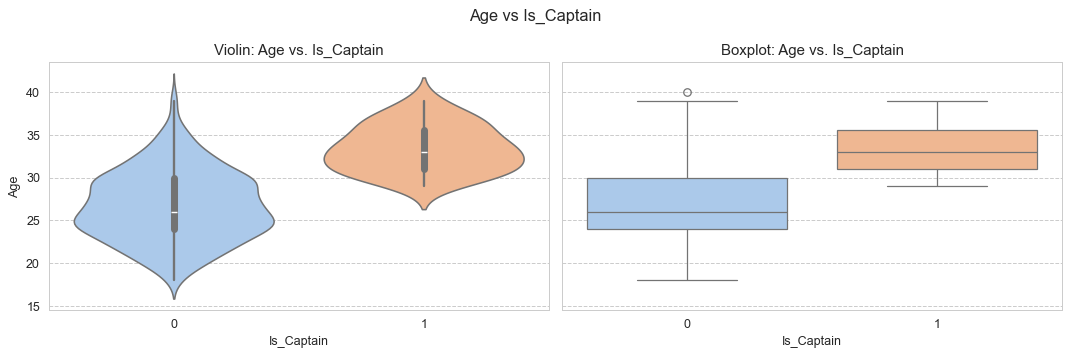

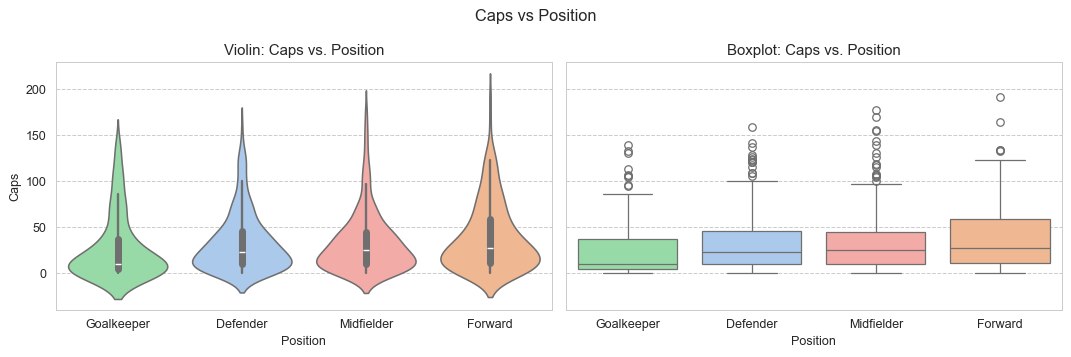

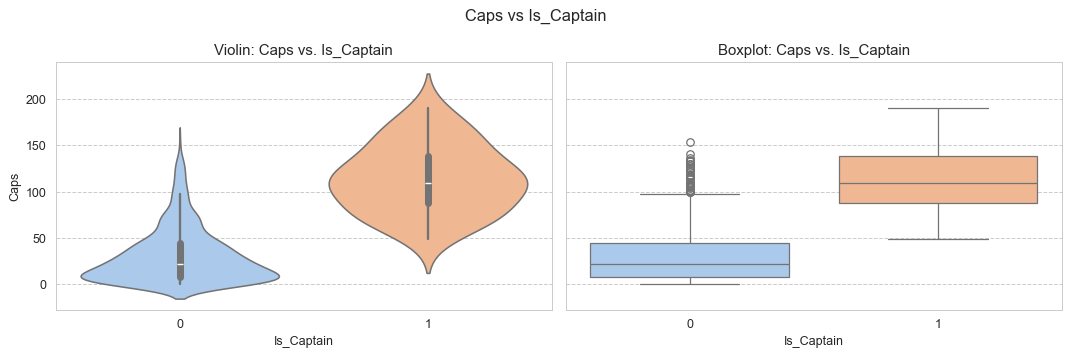

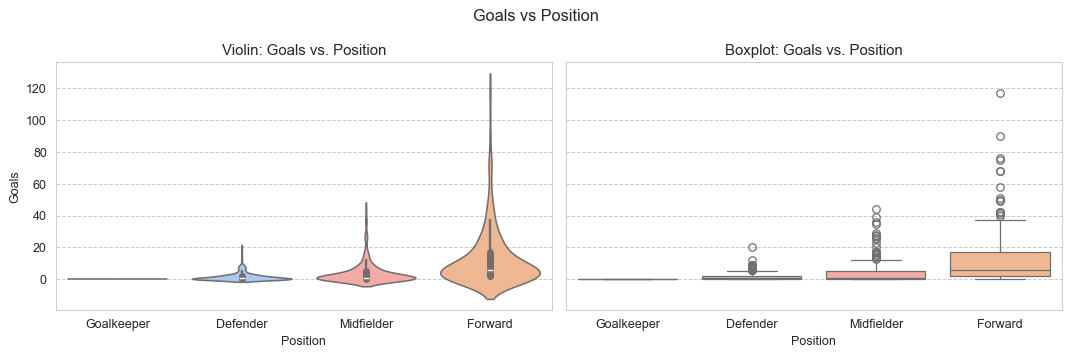

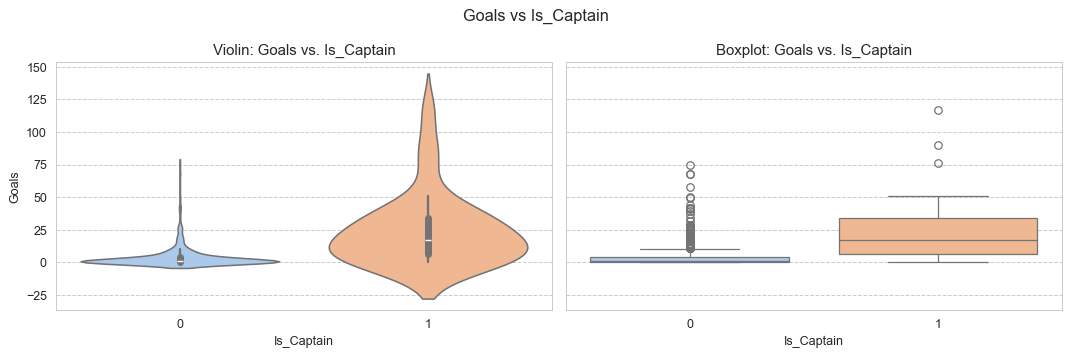

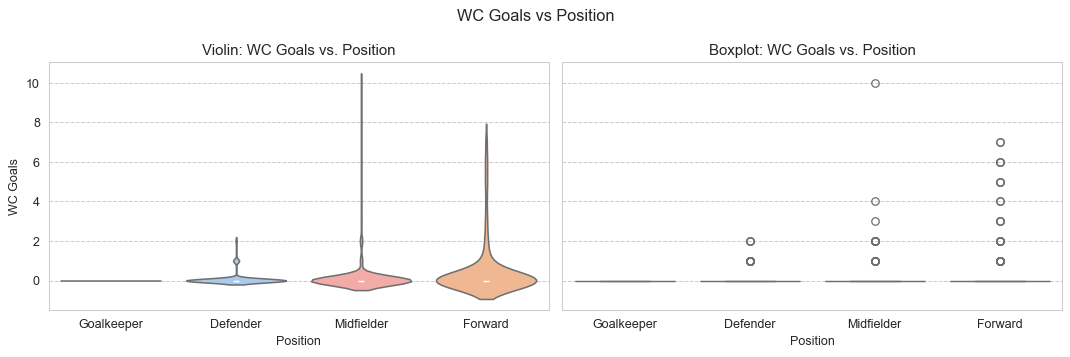

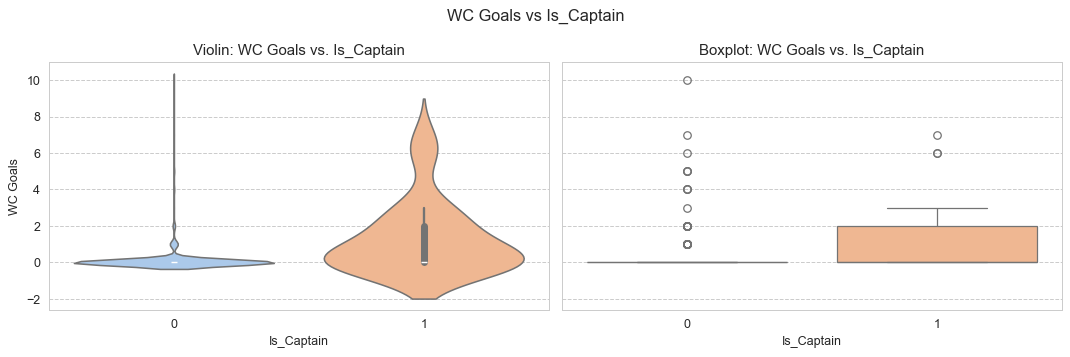

In [423]:
# Comparo cada numérica contra las dos categóricas con cardinalidad manejable.
cat_cols_vs_num = ['Position', 'Is_Captain']

for num in fifa_numericas:
    for cat in cat_cols_vs_num:
        order = POSITION_ORDER if cat == 'Position' else None
        plot_violin_box(fifa_df, num, cat, order=order)

#### Stripplot

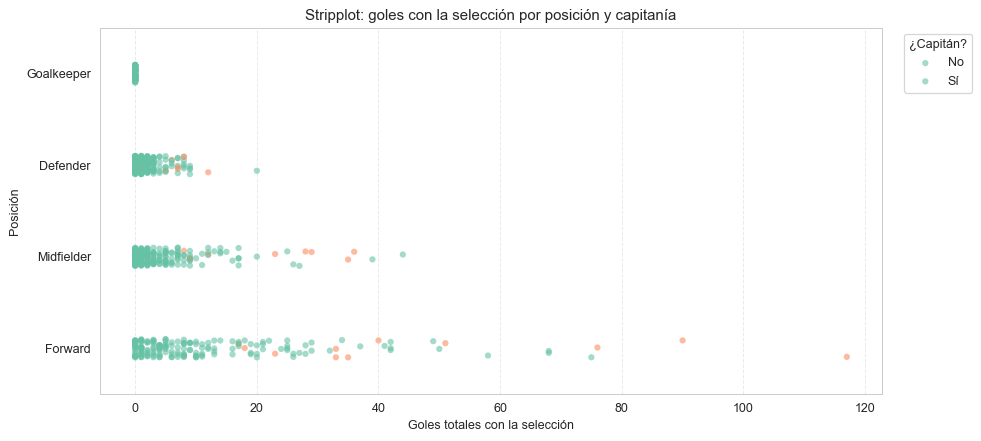

In [424]:
# Stripplot: cada jugador es un punto, posicionado por sus Goals con la selección,
# agrupado por Position. El hue (Is_Captain) resalta a los capitanes dentro de cada grupo
plt.figure(figsize=(11, 5))
sns.stripplot(data=fifa_df, x='Goals', y='Position',
              order=POSITION_ORDER, hue='Is_Captain',
              palette='Set2', alpha=0.6, size=5, jitter=True)

plt.title('Stripplot: goles con la selección por posición y capitanía')
plt.xlabel('Goles totales con la selección')
plt.ylabel('Posición')
plt.grid(axis='x', ls='--', alpha=0.4)
plt.legend(title='¿Capitán?', labels=['No', 'Sí'],
           bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

El stripplot dispersa los puntos en forma aleatoria en la dirección vertical (la posición en el eje $\texttt{y}$ no significa nada).

#### Swarmplot

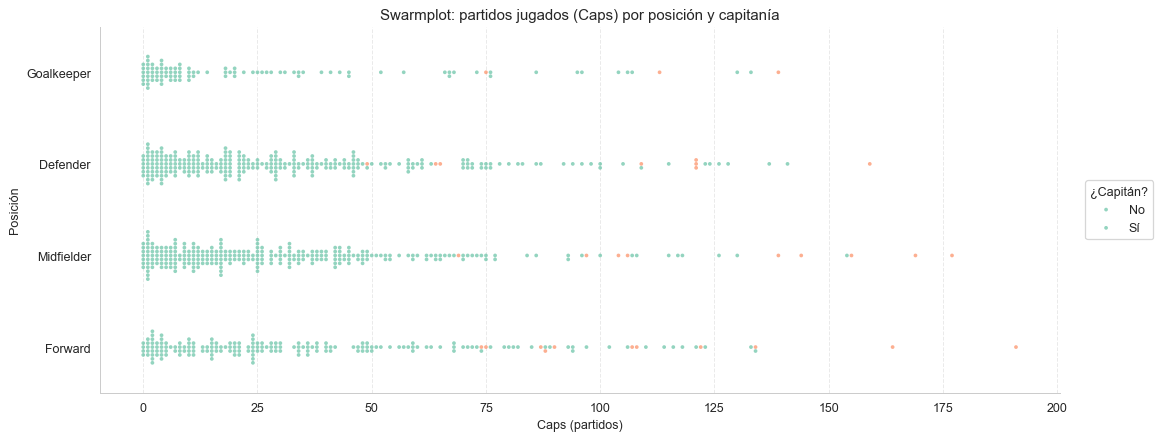

In [425]:
# Swarmplot: similar al stripplot pero distribuye los puntos verticalmente para
# que NUNCA se superpongan. Útil para ver la densidad real de cada grupo.
plt.figure(figsize=(13, 5))
sns.swarmplot(data=fifa_df, x='Caps', y='Position',
              order=POSITION_ORDER, hue='Is_Captain',
              palette='Set2', alpha=0.7, size=3)

plt.title('Swarmplot: partidos jugados (Caps) por posición y capitanía')
plt.xlabel('Caps (partidos)')
plt.ylabel('Posición')
plt.grid(axis='x', ls='--', alpha=0.4)
sns.despine()
plt.legend(title='¿Capitán?', labels=['No', 'Sí'],
           bbox_to_anchor=(1.02, 0.5), loc='center left')

plt.tight_layout()
plt.show()

En el swarmplot, se distribuyen los puntos en forma vertical de manera que nunca se superpongan. En general resulta más legible que el stripplot, pero es más lento.

---
## Síntesis del análisis numérica-categórica

- **`Age × Position`**: las distribuciones son bastante parecidas entre posiciones. Apenas hay una leve tendencia a que los arqueros sean un poco mayores en promedio, lo cual tiene sentido ya que los arqueros suelen tener mayore edad y tener una carrera más larga que los jugadores.

- **`Caps × Position`**: las cuatro distribuciones tienen la misma forma (sesgada a la derecha) pero los delanteros tienen una cola más larga. En general parecen muy parecidas.

- **`Goals × Position`**: acá el sesgo de la posición es muy grande. Los arqueros y defensores están casi todos cercanos al cero. Los mediocampistas muestran algo más de dispersión. Los delanteros son los únicos con cola larga (hasta 120 goles).

- **`Is_Captain`**: Los capitanes generalmente tienen valores más altos de `Age`, `Caps` y `Goals`. Esto tiene sentido ya que el capitán suele ser un jugador con experiencia.

---




## Conclusiones generales del EDA

1. **Las cuatro variables numéricas son muy distintas entre sí.** `Age` se aproxima a una normal; `Caps`, `Goals` y `WC Goals` son fuertemente sesgadas a la derecha con exceso de ceros.

2. **`Position` es la variable categórica con mayor poder de explicación.** Gran parte de la dispersión de `Goals` y `WC Goals` se puede explicar por la posición del jugador.

3. **`League` y `Club` son útiles para describir cómo está distribuido el mundo del fútbol top**, ya que la gran mayoría de los jugadores convocados pertenecen a las ligas top X.

4. **`Is_Captain` es informativa pero limitada**: solo hay 32 capitanes en la población de todos los jugadores.

5. **`Team`** termina siendo una variable casi puramente de agrupamiento.